#  **ĐỒ ÁN CUỐI KÌ PHA 1**

Thông tin các thành viên:
| Mã sinh viên | Họ và Tên        |
|--------------|------------------|
| 22120071     | Phan Bá Đức      |
| 22120078     | Nguyễn Bá Duy    |
| 22120182     | Đặng Duy Lân     |



**Tìm hiểu về dữ liệu**
| Thuộc tính                     | Mô tả                                                                                  | Kích thước                    |
|----------------------------------|---------------------------------------------------------------------------------------|------------------------------|
| **vid_id**                       | YouTube video ID liên quan đến mẫu dữ liệu này                                       | (n_sample, 1)               |
| **start_time_seconds_youtube_clip** | Thời điểm bắt đầu của đoạn audio trong video YouTube (tính bằng giây)               |(n_sample, 1)            |
| **end_time_seconds_youtube_clip**   | Thời điểm kết thúc của đoạn audio trong video YouTube (tính bằng giây)              |  (n_sample, 1)            |
| **audio_embedding**              | Đặc trưng âm thanh theo từng frame, giảm chiều xuống còn 128 chiều bằng VGGish       | (n_sample,frame, 128)              |
| **is_turkey**                   | Nhãn mục tiêu: 1 nếu đoạn audio chứa tiếng gà tây, 0 nếu không, dựa trên ontology AudioSet | Số thực (n_sample, 1)              |



### **Ý tưởng giải quyết vấn đề:**
#### **Cho dữ liệu:**
- Thuộc tính **audio_embedding và is_turkey** được giữa lại để đào tạo mô hình và loại bỏ các thuộc tính còn lại vì không mang ý nhiều ý nghĩa.
- Vấn đề xảy ra ở audio_embedding như đã phân tích ở trên có kích thước là (n_sample,frame, 128) khi thuộc tính is_turkey chỉ có (n_sample,1). Hơn nữa, số lượng frame là khác nhau ở các mỗi mẫu, điều này làm mất đi cân bằng số lượng giá trị. Phương án giải quyết:
    - Làm phẳng toàn bộ (frame, 128) ở mỗi mẫu, nghĩa là (n_sample,frame, 128) -> (n_sample,frame * 128), Nếu số lượng frame khác nhau thì lấp đầy toàn bộ bằng số 0. đảm bảo cùng số lượng phần tử ở mỗi mẫu.
    - Ở đây vấn đề tiếp tục xảy ra khi dữ liệu ở (n_sample,frame * 128) số cột (frame * 128) lại quá lớn. Phương án giải quyết:
        - Dùng thuật toán PCA để giảm chiều dữ liệu, trực quan để lựa chọn số chiều phù hợp, đảm bảo giữa lại được nhiều thông tin.
#### **Cho việc xây dựng mô hình:**
- Dữ liệu chỉ có 1195 mẫu, thực sự quá ít. Phương án là dùng Cross Validation, cho cả tập train và tập validate
- Số lớp của dữ liệu là 2 và phân bổ 0 : 704 mẫu, 1 : 491 mẫu. Có sự mất cân bằng rất nhỏ, không ảnh hưởng nhiều.
- Dùng Grid Search, phương thức kết hợp Cross Validation, đánh giá accuracy và đào tạo mô hình trên những tham số khác nhau.

## **1. Import thư viện và đọc và phân tích dữ liệu**

In [85]:
import json
import numpy as np
import pandas as pd
from matplotlib.pylab import plt 
import seaborn as sns
import time
import psutil
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import tracemalloc

In [86]:
sns.set_theme()

In [87]:
# Đọc dữ liệu
with open("/kaggle/input/introduction-to-machine-learning-project-cq-24-2/train.json", "r") as f:
    train_data = json.load(f)

# chuyển về dataframe 
train_data = pd.DataFrame(train_data)

In [88]:
# kích thước của dữ liệu.
train_data.shape 

(1195, 5)

In [89]:
# xem xét kích thước của feature audio_embedding ở mỗi mẫu
audio_embedding_shape = np.array(train_data["audio_embedding"][0]).shape
print(audio_embedding_shape)

(10, 128)


Đa số là 10 frame và mỗi frame có 128 chiều. **Ngoài ra sau khi tìm hiểu về dữ liệu thì số frame lại khác nhau**. 

<Axes: >

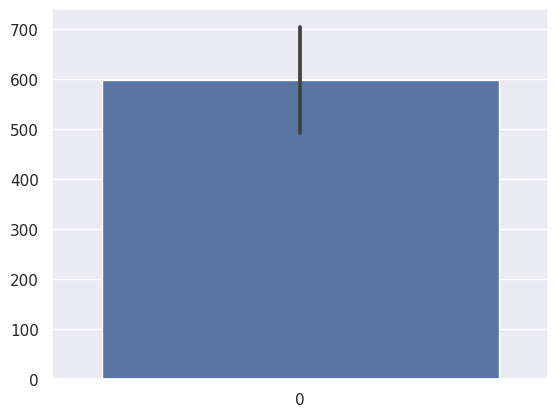

In [90]:
# xem xét nhãn
label = train_data["is_turkey"].value_counts()
sns.barplot(label)

## **2. Tiền xử lý dữ liệu**

- Vấn đề xảy ra ở audio_embedding như đã phân tích ở trên có kích thước là (n_sample,frame, 128) khi thuộc tính is_turkey chỉ có (n_sample,1). Hơn nữa, số lượng frame là khác nhau ở các mỗi mẫu, điều này làm mất đi cân bằng số lượng giá trị. Phương án giải quyết:
    - Làm phẳng toàn bộ (frame, 128) ở mỗi mẫu, nghĩa là (n_sample,frame, 128) -> (n_sample,frame * 128), Nếu số lượng frame khác nhau thì lấp đầy toàn bộ bằng số 0. đảm bảo cùng số lượng phần tử ở mỗi mẫu.
    - Ở đây vấn đề tiếp tục xảy ra khi dữ liệu ở (n_sample,frame * 128) số cột (frame * 128) lại quá lớn. Phương án giải quyết:
        - Dùng thuật toán PCA để giảm chiều dữ liệu, trực quan để lựa chọn số chiều phù hợp, đảm bảo giữa lại được nhiều thông tin.

In [91]:
class PCA_Preprocessing:
    def __init__(self, target_length=1280, reduced_dim=350):
        self.target_length = target_length # độ dài tối đa của mỗi mẫu embedding, vì số frame là khác nhau, nên cố đinh là 1280
        self.scaler = StandardScaler() # chuẩn hoá dữ liệu
        self.pca = PCA(n_components=reduced_dim) # đưa vào PCA để trích xuất đặc trưng
        self.is_fitted = False # cờ để nhận biết tập train và tập test

    # làm phẳng dữ liệu ở mỗi embedding (frame, 128) thành (frame * 128), 
    # khác số frame thì lấp toàn bộ bằng 0
    def flatten_and_pad(self, embedding):
        # embedding: array/list shape (frame, 128)
        flattened = [val for sublist in embedding for val in sublist]
        if len(flattened) < self.target_length:
            flattened += [0] * (self.target_length - len(flattened))
        else:
            flattened = flattened[:self.target_length]
        return flattened

    # hàm chính xử lý dữ liệu 
    def __call__(self, df: pd.DataFrame, train=True):
        X = []
        y = []

        # làm phẳng thuộc tính cho mỗi phần tử của audio_embedding
        for idx, row in df.iterrows():
            embedding = row["audio_embedding"]
            x_vec = self.flatten_and_pad(embedding)
            X.append(x_vec) 
            if train:
                y.append(row["is_turkey"])

        X = np.array(X)
        
        if train:
            y = np.array(y)
            X_scaled = self.scaler.fit_transform(X) # chuẩn hoá dữ liệu 
            X_reduced = self.pca.fit_transform(X_scaled) # fit dựa trên thuật toán PCA
            self.is_fitted = True # bật cờ, báo thể hiện đã fit trên tập train, mục tiêu cố định kiểu, và số chiều
            return X_reduced, y
        else:
            if not self.is_fitted:
                raise ValueError("Bạn phải gọi class này với train=True trước khi dùng test.")
            X_scaled = self.scaler.transform(X) # chuẩn hoá 
            X_reduced = self.pca.transform(X_scaled) # dùng PCA trên tập test, chuẩn hoá theo kiểu trên tập train 
            return X_reduced


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


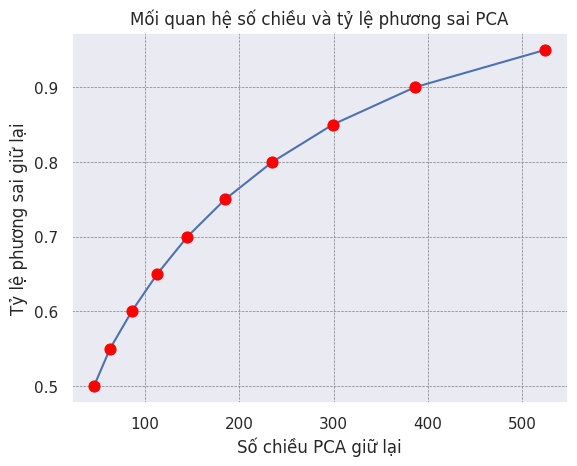

In [92]:
# mục tiêu quan sát số chiều và thông tin giữa lại tương ứng với số chiều
information = np.arange(0.5, 1, 0.05) # thông tin được giữa lại từ 0.5 đến 0.95
num_dims = [] # số chiều 

# thu thập dữ liệu và số chiều còn lại
for infor in information:
    prepro = PCA_Preprocessing(reduced_dim = infor)
    X_check,y_check = prepro(train_data)
    num_dims.append(np.array(X_check).shape[1])

# vẽ biểu đồ quan sát
sns.lineplot(x=num_dims, y=information, marker='o', markersize=8, markerfacecolor='red', markeredgecolor='red')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.xlabel("Số chiều PCA giữ lại")
plt.ylabel("Tỷ lệ phương sai giữ lại")
plt.title("Mối quan hệ số chiều và tỷ lệ phương sai PCA")
plt.show()

**Thông qua trực quan ở trên, chúng em chọn giữa lại ~87% thông tin của dữ liệu, với số chiều là 340.**

In [93]:
preprocessor = PCA_Preprocessing(reduced_dim = 340)
X, y = preprocessor(train_data, train=True)
X.shape

(1195, 340)

In [94]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## **3. Train mô hình**

- Dữ liệu chỉ có 1195 mẫu, thực sự quá ít. Phương án là dùng Cross Validation, cho cả tập train và tập validate
- Số lớp của dữ liệu là 2 và phân bổ 0 : 704 mẫu, 1 : 491 mẫu. Có sự mất cân bằng rất nhỏ,Có sự mất cân bằng rất nhỏ, không ảnh hưởng nhiều.
- Dùng Grid Search, phương thức kết hợp Cross Validation, đánh giá accuracy và đào tạo mô hình trên những tham số khác nhau. Từ đó tìm ra mô hình tốt nhất
- Việc chia tập train và tập validata cũng không có ý nghĩa với dữ liệu quá nhỏ này, vì đã có Cross Validation duyệt theo 5-Folds.

In [95]:
# định nghĩa các mô hình và tham số tương ứng 
models_params = {
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            "n_estimators": [100, 200],
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 5]
        }
    ),
    "SVM": (
        SVC(probability=True, random_state=42),
        {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"]
        }
    ),
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, random_state=42),
        {
            "C": [0.01, 0.1, 1, 10],
            "penalty": ["l2"],
            "solver": ["lbfgs"]
        }
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 5],
            "criterion": ["gini", "entropy"]
        }
    ),
}


In [96]:
def train_models_with_gridsearch(X_train, y_train, models_params, cv=5, scoring='accuracy'):
    best_models = {}
    scores = {}
    times = {}
    memories = {}

    pid = psutil.Process().pid

    for name, (model, param_grid) in models_params.items():
        print(f"Training model {name} with GridSearchCV:")

        # Đo bộ nhớ trước
        try:
            process = psutil.Process(pid)
            mem_before = process.memory_info().rss
            for child in process.children(recursive=True):
                mem_before += child.memory_info().rss
            mem_before /= (1024 * 1024)  # MB
        except Exception as e:
            print(f"Error getting memory before training: {e}")
            mem_before = 0

        start_time = time.time()

        grid = GridSearchCV(model, param_grid, cv=cv, scoring=scoring, n_jobs=-1)
        grid.fit(X_train, y_train)

        elapsed = time.time() - start_time

        # Đo bộ nhớ sau
        try:
            process = psutil.Process(pid)
            mem_after = process.memory_info().rss
            for child in process.children(recursive=True):
                mem_after += child.memory_info().rss
            mem_after /= (1024 * 1024)  # MB
        except Exception as e:
            print(f"Error getting memory after training: {e}")
            mem_after = 0

        best_model = grid.best_estimator_
        best_models[name] = best_model

        print(f"Best params for {name}: {grid.best_params_}")
        print(f"Best CV {scoring} for {name}: {grid.best_score_:.4f}")
        print(f"Time taken for {name}: {elapsed:.2f} seconds")
        print(f"Memory usage change for {name}: {mem_after - mem_before:.2f} MB\n")

        scores[name] = grid.best_score_
        times[name] = elapsed
        memories[name] = mem_after - mem_before

    return best_models, scores, times, memories

# Gọi hàm
best_models, scores, times, memories = train_models_with_gridsearch(X_train, y_train, models_params)


Training model Random Forest with GridSearchCV:
Best params for Random Forest: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best CV accuracy for Random Forest: 0.9404
Time taken for Random Forest: 32.62 seconds
Memory usage change for Random Forest: 539.27 MB

Training model SVM with GridSearchCV:
Best params for SVM: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV accuracy for SVM: 0.9393
Time taken for SVM: 8.83 seconds
Memory usage change for SVM: 10.99 MB

Training model Logistic Regression with GridSearchCV:
Best params for Logistic Regression: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV accuracy for Logistic Regression: 0.9425
Time taken for Logistic Regression: 0.53 seconds
Memory usage change for Logistic Regression: 4.00 MB

Training model Decision Tree with GridSearchCV:
Best params for Decision Tree: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 2}
Best CV accuracy for Decision Tree: 0.9226
Time taken for Decision Tree: 3.

In [97]:
# Chuyển từ dic thành DataFrame để trực quan
df_results = pd.DataFrame({
    'Model': list(scores.keys()),
    'Best CV Accuracy': list(scores.values()),
    'Training Time (s)': list(times.values()),
    'Memory Usage (MB)': list(memories.values()),
})
df_results.head(5)

,Model,Best CV Accuracy,Training Time (s),Memory Usage (MB)
0,Random Forest,0.940385,32.623086,539.273438
1,SVM,0.939322,8.831244,10.992188
2,Logistic Regression,0.942474,0.532250,4.000000
3,Decision Tree,0.922606,3.787512,0.000000


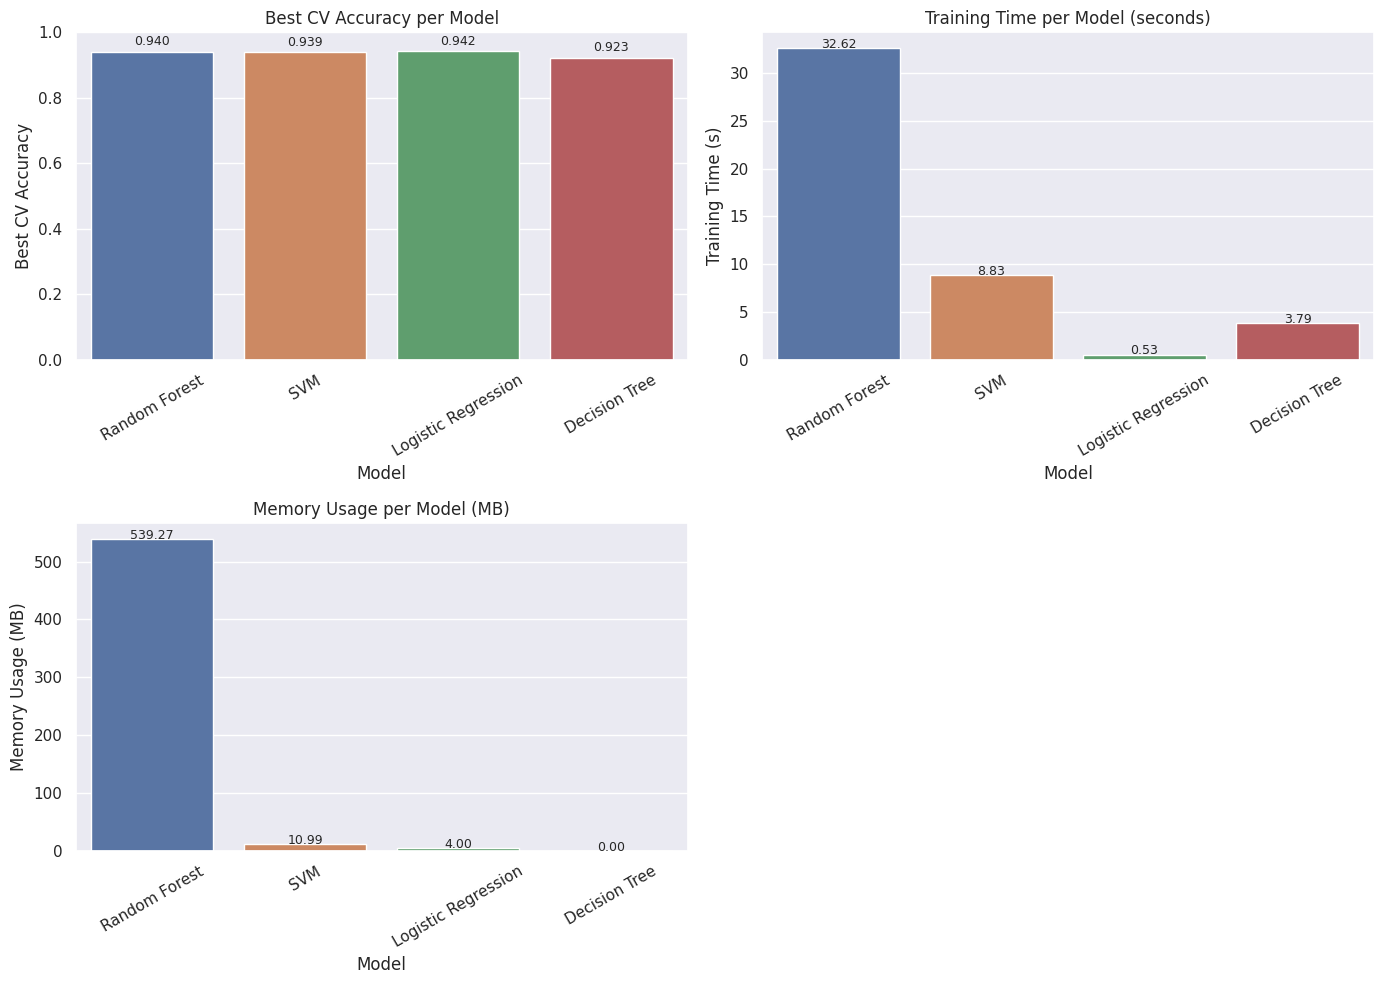

In [98]:
plt.figure(figsize=(14,10))

# Biểu đồ 1: Best CV Accuracy
plt.subplot(2, 2, 1)
ax1 = sns.barplot(x='Model', y='Best CV Accuracy', data=df_results)
plt.title('Best CV Accuracy per Model')
plt.ylim(0,1)
plt.xticks(rotation=30)

for p in ax1.patches:
    height = p.get_height()
    ax1.text(p.get_x() + p.get_width()/2., height + 0.02, 
             f'{height:.3f}', ha='center', fontsize=9)

# Biểu đồ 2: Training Time
plt.subplot(2, 2, 2)
ax2 = sns.barplot(x='Model', y='Training Time (s)', data=df_results)
plt.title('Training Time per Model (seconds)')
plt.xticks(rotation=30)

for p in ax2.patches:
    height = p.get_height()
    ax2.text(p.get_x() + p.get_width()/2., height + 0.02, 
             f'{height:.2f}', ha='center', fontsize=9)

# Biểu đồ 3: Memory Usage
plt.subplot(2, 2, 3)
ax3 = sns.barplot(x='Model', y='Memory Usage (MB)', data=df_results)
plt.title('Memory Usage per Model (MB)')
plt.xticks(rotation=30)

for p in ax3.patches:
    height = p.get_height()
    ax3.text(p.get_x() + p.get_width()/2., height + 0.02, 
             f'{height:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


**Theo như trực quan ở trên thì 2 mô hình Random Forest và Logistic Regression cho ra kết quả tốt như nhau. Nhưng đổi lại Logistic Regression có thời gian chạy nhanh hơn gần như 60 lần so với Random Forest**

**Do đó mô hình mà chúng em chọn là Logistic Regression.**

In [99]:
bes_model = best_models["Logistic Regression"]

**Cùng nhìn performance của mô hình trên tập test để đánh giá cuối cùng, thông qua kĩ thuật cross validation**

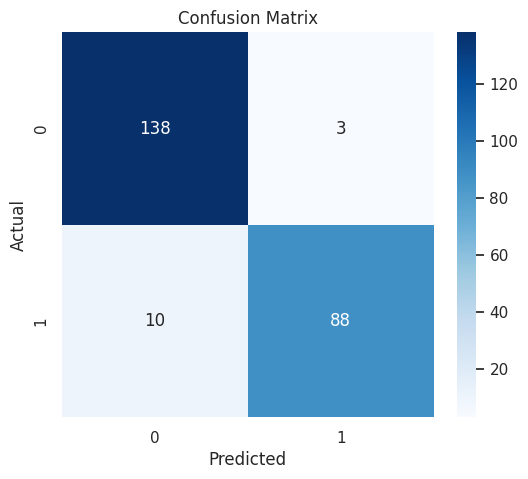

In [100]:
# Dự đoán nhãn trên test set
y_pred = bes_model.predict(X_valid)

# Tính confusion matrix
cm = confusion_matrix(y_valid, y_pred)

# Vẽ confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

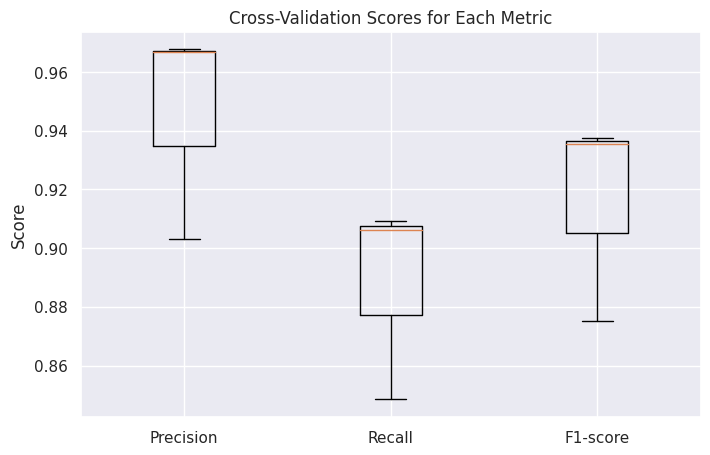

In [101]:
metrics = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

# Cross-validation
cv_results = cross_validate(bes_model, X_valid, y_valid, cv=3, scoring=metrics)

# Lấy kết quả các metric
precision_scores = cv_results['test_precision']
recall_scores = cv_results['test_recall']
f1_scores = cv_results['test_f1']

# Vẽ boxplot
plt.figure(figsize=(8, 5))
plt.boxplot([precision_scores, recall_scores, f1_scores], labels=['Precision', 'Recall', 'F1-score'])
plt.title('Cross-Validation Scores for Each Metric')
plt.ylabel('Score')
plt.grid(True)
plt.show()

- Như đã phân tích ở trên thì dữ liệu này khá là ít và việc bias là chuyện bình thường.
- Tập trung vào đường trung vị màu đỏ, giá trị trung tâm của các metrics khá tốt Precision khoảng 0.943 và recall khoảng 0.945, F1: 0.924.
- Kết luận: mô hình không gặp các vấn đề như overfitting và performance khá tốt.

## **4. Dự đoán trên tập test**

In [102]:
# Đọc dữ liệu
with open("/kaggle/input/introduction-to-machine-learning-project-cq-24-2/test.json", "r") as f:
    test_data = json.load(f)

test_data = pd.DataFrame(test_data)
X_test = preprocessor(test_data, train= False)
X_test.shape

(1196, 340)

In [103]:
y_pre = bes_model.predict(X_test)
y_pre[0:15]

array([0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0])

In [104]:
y_pro = bes_model.predict_proba(X_test)[:, 1] # index 1 là xác suất ở cột 1 
y_pro_pre= (y_pro > 0.5).astype(int)
# kết quả
submit_df = pd.DataFrame({
    "vid_id": test_data['vid_id'].values,  # giữ nguyên 1 chiều
    "is_turkey": np.array(y_pro), # xác suất
})

# kiểm tra 5 dòng đầu  
submit_df.head(5)

,vid_id,is_turkey
0,pyKh38FXD3E,0.000369
1,THhP1idrWXA,0.000220
2,jsw3T6GY2Nw,0.019500
3,nFkXTMHcjMU,0.002163
4,Au8g9kAlrLQ,0.665178


In [105]:
# lưu file
submit_df.to_csv("22120071_22120078_22120182.csv", index=False)